# COMP 576 — Assignment 0
**Jiaxuan Wen**

Task 2: NumPy *Linear Algebra Equivalents* (every Python command in the table of
[NumPy for MATLAB users](https://numpy.org/doc/stable/user/numpy-for-matlab-users.html)).
Task 3: the required Matplotlib program. Task 4: a Matplotlib figure of my own.

## Task 2 — NumPy linear algebra equivalents
### Setup: the matrices used below

In [1]:
import numpy as np
from numpy import linalg
import scipy.linalg
from scipy import signal
from scipy.sparse.linalg import eigs, cg

np.set_printoptions(precision=4, suppress=True, linewidth=110)

a = np.arange(1., 61.).reshape(6, 10)          # 6x10 array for indexing examples
v = np.array([0.2, 0.9, 0.4, 0.7, 0.1, 0.6, 0.8, 0.3, 0.55, 0.05])  # length-10 vector
M = np.array([[4., 1., 2.],                     # 3x3 symmetric positive-definite matrix
              [1., 3., 0.],
              [2., 0., 5.]])
b3 = np.array([1., 2., 3.])
print("a =\n", a)
print("v =", v)
print("M =\n", M)

a =
 [[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
 [11. 12. 13. 14. 15. 16. 17. 18. 19. 20.]
 [21. 22. 23. 24. 25. 26. 27. 28. 29. 30.]
 [31. 32. 33. 34. 35. 36. 37. 38. 39. 40.]
 [41. 42. 43. 44. 45. 46. 47. 48. 49. 50.]
 [51. 52. 53. 54. 55. 56. 57. 58. 59. 60.]]
v = [0.2  0.9  0.4  0.7  0.1  0.6  0.8  0.3  0.55 0.05]
M =
 [[4. 1. 2.]
 [1. 3. 0.]
 [2. 0. 5.]]


### Array size and shape

In [2]:
print("np.ndim(a) =", np.ndim(a), "| a.ndim =", a.ndim)                  # ndims(a)
print("np.size(a) =", np.size(a), "| a.size =", a.size)                  # numel(a)
print("np.shape(a) =", np.shape(a), "| a.shape =", a.shape)              # size(a)
n = 2
print("a.shape[n-1] (n=2) =", a.shape[n-1])                              # size(a,n)

np.ndim(a) = 2 | a.ndim = 2
np.size(a) = 60 | a.size = 60
np.shape(a) = (6, 10) | a.shape = (6, 10)
a.shape[n-1] (n=2) = 10


### Building arrays

In [3]:
print(np.array([[1., 2., 3.], [4., 5., 6.]]))                            # [ 1 2 3; 4 5 6 ]
A = np.eye(2); B = np.zeros((2, 3)); C = np.ones((1, 2)); D = np.full((1, 3), 7.)
print(np.block([[A, B], [C, D]]))                                        # [ a b; c d ]

[[1. 2. 3.]
 [4. 5. 6.]]
[[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [1. 1. 7. 7. 7.]]


### Indexing and slicing

In [4]:
print("a[-1] =", a[-1])                          # a(end)  (last row of 2D a)
print("v[-1] =", v[-1])                          # a(end)  for a 1D vector
print("a[1, 4] =", a[1, 4])                      # a(2,5)
print("a[1] =", a[1])                            # a(2,:)
print("a[1, :] =", a[1, :])
print("a[0:5] =\n", a[0:5])                     # a(1:5,:)
print("a[:5] =\n", a[:5])
print("a[0:5, :] =\n", a[0:5, :])

a[-1] = [51. 52. 53. 54. 55. 56. 57. 58. 59. 60.]
v[-1] = 0.05
a[1, 4] = 15.0
a[1] = [11. 12. 13. 14. 15. 16. 17. 18. 19. 20.]
a[1, :] = [11. 12. 13. 14. 15. 16. 17. 18. 19. 20.]
a[0:5] =
 [[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
 [11. 12. 13. 14. 15. 16. 17. 18. 19. 20.]
 [21. 22. 23. 24. 25. 26. 27. 28. 29. 30.]
 [31. 32. 33. 34. 35. 36. 37. 38. 39. 40.]
 [41. 42. 43. 44. 45. 46. 47. 48. 49. 50.]]
a[:5] =
 [[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
 [11. 12. 13. 14. 15. 16. 17. 18. 19. 20.]
 [21. 22. 23. 24. 25. 26. 27. 28. 29. 30.]
 [31. 32. 33. 34. 35. 36. 37. 38. 39. 40.]
 [41. 42. 43. 44. 45. 46. 47. 48. 49. 50.]]
a[0:5, :] =
 [[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
 [11. 12. 13. 14. 15. 16. 17. 18. 19. 20.]
 [21. 22. 23. 24. 25. 26. 27. 28. 29. 30.]
 [31. 32. 33. 34. 35. 36. 37. 38. 39. 40.]
 [41. 42. 43. 44. 45. 46. 47. 48. 49. 50.]]


In [5]:
print("a[-5:] =\n", a[-5:])                               # a(end-4:end,:)
print("a[0:3, 4:9] =\n", a[0:3, 4:9])                     # a(1:3,5:9)
print("a[np.ix_([1, 3, 4], [0, 2])] =\n", a[np.ix_([1, 3, 4], [0, 2])])   # a([2,4,5],[1,3])
print("a[2:21:2,:] =\n", a[2:21:2,:])                     # a(3:2:21,:)
print("a[::2, :] =\n", a[::2, :])                         # a(1:2:end,:)
print("a[::-1,:] =\n", a[::-1,:])                         # a(end:-1:1,:) or flipud(a)
print("a[np.r_[:len(a),0]] =\n", a[np.r_[:len(a),0]])     # a([1:end 1],:)

a[-5:] =
 [[11. 12. 13. 14. 15. 16. 17. 18. 19. 20.]
 [21. 22. 23. 24. 25. 26. 27. 28. 29. 30.]
 [31. 32. 33. 34. 35. 36. 37. 38. 39. 40.]
 [41. 42. 43. 44. 45. 46. 47. 48. 49. 50.]
 [51. 52. 53. 54. 55. 56. 57. 58. 59. 60.]]
a[0:3, 4:9] =
 [[ 5.  6.  7.  8.  9.]
 [15. 16. 17. 18. 19.]
 [25. 26. 27. 28. 29.]]
a[np.ix_([1, 3, 4], [0, 2])] =
 [[11. 13.]
 [31. 33.]
 [41. 43.]]
a[2:21:2,:] =
 [[21. 22. 23. 24. 25. 26. 27. 28. 29. 30.]
 [41. 42. 43. 44. 45. 46. 47. 48. 49. 50.]]
a[::2, :] =
 [[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
 [21. 22. 23. 24. 25. 26. 27. 28. 29. 30.]
 [41. 42. 43. 44. 45. 46. 47. 48. 49. 50.]]
a[::-1,:] =
 [[51. 52. 53. 54. 55. 56. 57. 58. 59. 60.]
 [41. 42. 43. 44. 45. 46. 47. 48. 49. 50.]
 [31. 32. 33. 34. 35. 36. 37. 38. 39. 40.]
 [21. 22. 23. 24. 25. 26. 27. 28. 29. 30.]
 [11. 12. 13. 14. 15. 16. 17. 18. 19. 20.]
 [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]]
a[np.r_[:len(a),0]] =
 [[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
 [11. 12. 13. 14. 15. 16. 17. 18. 19. 20

### Transpose and element-wise operations

In [6]:
c = np.array([[1+2j, 3-1j], [0+1j, 4+0j]])
print("a.transpose().shape =", a.transpose().shape, "| a.T.shape =", a.T.shape)   # a.'
print("c.conj().transpose() =\n", c.conj().transpose())                        # a'
print("c.conj().T =\n", c.conj().T)
x = np.array([[1., 2.], [3., 4.]]); y = np.array([[5., 6.], [7., 8.]])
print("x @ y =\n", x @ y)            # a * b   (matrix multiply)
print("x * y =\n", x * y)            # a .* b
print("x / y =\n", x / y)            # a./b
print("x**3 =\n", x**3)              # a.^3

a.transpose().shape = (10, 6) | a.T.shape = (10, 6)
c.conj().transpose() =
 [[1.-2.j 0.-1.j]
 [3.+1.j 4.-0.j]]
c.conj().T =
 [[1.-2.j 0.-1.j]
 [3.+1.j 4.-0.j]]
x @ y =
 [[19. 22.]
 [43. 50.]]
x * y =
 [[ 5. 12.]
 [21. 32.]]
x / y =
 [[0.2    0.3333]
 [0.4286 0.5   ]]
x**3 =
 [[ 1.  8.]
 [27. 64.]]


### Logical indexing and assignment

In [7]:
rng = np.random.default_rng(0)
r = rng.random((3, 4))
print("r =\n", r)
print("(r > 0.5) =\n", (r > 0.5))                                   # (a > 0.5)
print("np.nonzero(r > 0.5) =", np.nonzero(r > 0.5))                  # find(a > 0.5)
print("a[:,np.nonzero(v > 0.5)[0]] =\n", a[:,np.nonzero(v > 0.5)[0]])   # a(:,find(v > 0.5))
print("a[:, v.T > 0.5] =\n", a[:, v.T > 0.5])                        # a(:,find(v>0.5))

r =
 [[0.637  0.2698 0.041  0.0165]
 [0.8133 0.9128 0.6066 0.7295]
 [0.5436 0.9351 0.8159 0.0027]]
(r > 0.5) =
 [[ True False False False]
 [ True  True  True  True]
 [ True  True  True False]]
np.nonzero(r > 0.5) = (array([0, 1, 1, 1, 1, 2, 2, 2]), array([0, 0, 1, 2, 3, 0, 1, 2]))
a[:,np.nonzero(v > 0.5)[0]] =
 [[ 2.  4.  6.  7.  9.]
 [12. 14. 16. 17. 19.]
 [22. 24. 26. 27. 29.]
 [32. 34. 36. 37. 39.]
 [42. 44. 46. 47. 49.]
 [52. 54. 56. 57. 59.]]
a[:, v.T > 0.5] =
 [[ 2.  4.  6.  7.  9.]
 [12. 14. 16. 17. 19.]
 [22. 24. 26. 27. 29.]
 [32. 34. 36. 37. 39.]
 [42. 44. 46. 47. 49.]
 [52. 54. 56. 57. 59.]]


In [8]:
r1 = r.copy(); r1[r1 < 0.5] = 0                                      # a(a<0.5)=0
print("r[r < 0.5]=0 ->\n", r1)
print("r * (r > 0.5) =\n", r * (r > 0.5))                           # a .* (a>0.5)
r2 = r.copy(); r2[:] = 3                                             # a(:) = 3
print("r[:] = 3 ->\n", r2)

r[r < 0.5]=0 ->
 [[0.637  0.     0.     0.    ]
 [0.8133 0.9128 0.6066 0.7295]
 [0.5436 0.9351 0.8159 0.    ]]
r * (r > 0.5) =
 [[0.637  0.     0.     0.    ]
 [0.8133 0.9128 0.6066 0.7295]
 [0.5436 0.9351 0.8159 0.    ]]
r[:] = 3 ->
 [[3. 3. 3. 3.]
 [3. 3. 3. 3.]
 [3. 3. 3. 3.]]


### Copies and flattening

In [9]:
x = np.array([[1., 2., 3.], [4., 5., 6.]])
y = x.copy()                    # y=x
y[0, 0] = 99
print("y = x.copy(); y[0,0]=99 -> x unchanged:\n", x)
y = x[1, :].copy()              # y=x(2,:)
print("y = x[1, :].copy() =", y)
y = x.flatten()                 # y=x(:)
print("x.flatten() =", y)
print("x.flatten('F') =", x.flatten('F'))

y = x.copy(); y[0,0]=99 -> x unchanged:
 [[1. 2. 3.]
 [4. 5. 6.]]
y = x[1, :].copy() = [4. 5. 6.]
x.flatten() = [1. 2. 3. 4. 5. 6.]
x.flatten('F') = [1. 4. 2. 5. 3. 6.]


### Ranges, grids and constructors

In [10]:
print("np.arange(1., 11.) =", np.arange(1., 11.))          # 1:10
print("np.r_[1.:11.] =", np.r_[1.:11.])
print("np.r_[1:10:10j] =", np.r_[1:10:10j])
print("np.arange(10.) =", np.arange(10.))                  # 0:9
print("np.r_[:10.] =", np.r_[:10.])
print("np.r_[:9:10j] =", np.r_[:9:10j])
print("np.arange(1.,11.)[:, np.newaxis] =\n", np.arange(1.,11.)[:, np.newaxis])   # [1:10]'

np.arange(1., 11.) = [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
np.r_[1.:11.] = [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
np.r_[1:10:10j] = [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
np.arange(10.) = [0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
np.r_[:10.] = [0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
np.r_[:9:10j] = [0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
np.arange(1.,11.)[:, np.newaxis] =
 [[ 1.]
 [ 2.]
 [ 3.]
 [ 4.]
 [ 5.]
 [ 6.]
 [ 7.]
 [ 8.]
 [ 9.]
 [10.]]


In [11]:
print("np.zeros((3, 4)) =\n", np.zeros((3, 4)))            # zeros(3,4)
print("np.zeros((3, 4, 5)).shape =", np.zeros((3, 4, 5)).shape)   # zeros(3,4,5)
print(np.zeros((3, 4, 5)))
print("np.ones((3, 4)) =\n", np.ones((3, 4)))              # ones(3,4)
print("np.eye(3) =\n", np.eye(3))                          # eye(3)
print("np.diag(M) =", np.diag(M))                           # diag(a)
print("np.diag(b3, 0) =\n", np.diag(b3, 0))                # diag(v,0)

np.zeros((3, 4)) =
 [[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
np.zeros((3, 4, 5)).shape = (3, 4, 5)
[[[0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]]

 [[0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]]

 [[0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]]]
np.ones((3, 4)) =
 [[1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]]
np.eye(3) =
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
np.diag(M) = [4. 3. 5.]
np.diag(b3, 0) =
 [[1. 0. 0.]
 [0. 2. 0.]
 [0. 0. 3.]]


In [12]:
from numpy.random import default_rng                       # rng(42,'twister'); rand(3,4)
rng = default_rng(42)
print("rng.random((3, 4)) =\n", rng.random((3, 4)))
np.random.seed(42)
print("older version np.random.rand(3, 4) =\n", np.random.rand(3, 4))
print("np.linspace(1,3,4) =", np.linspace(1,3,4))           # linspace(1,3,4)

rng.random((3, 4)) =
 [[0.774  0.4389 0.8586 0.6974]
 [0.0942 0.9756 0.7611 0.7861]
 [0.1281 0.4504 0.3708 0.9268]]
older version np.random.rand(3, 4) =
 [[0.3745 0.9507 0.732  0.5987]
 [0.156  0.156  0.0581 0.8662]
 [0.6011 0.7081 0.0206 0.9699]]
np.linspace(1,3,4) = [1.     1.6667 2.3333 3.    ]


In [13]:
print("np.mgrid[0:9.,0:6.] =\n", np.mgrid[0:9.,0:6.])       # [x,y]=meshgrid(0:8,0:5)
print("np.meshgrid(np.r_[0:9.],np.r_[0:6.]) =\n", np.meshgrid(np.r_[0:9.],np.r_[0:6.]))
print("np.ogrid[0:9.,0:6.] =", np.ogrid[0:9.,0:6.])
print("np.ix_(np.r_[0:9.],np.r_[0:6.]) =", np.ix_(np.r_[0:9.],np.r_[0:6.]))
print("np.meshgrid([1,2,4],[2,4,5]) =", np.meshgrid([1,2,4],[2,4,5]))   # [x,y]=meshgrid([1,2,4],[2,4,5])
print("np.ix_([1,2,4],[2,4,5]) =", np.ix_([1,2,4],[2,4,5]))

np.mgrid[0:9.,0:6.] =
 [[[0. 0. 0. 0. 0. 0.]
  [1. 1. 1. 1. 1. 1.]
  [2. 2. 2. 2. 2. 2.]
  [3. 3. 3. 3. 3. 3.]
  [4. 4. 4. 4. 4. 4.]
  [5. 5. 5. 5. 5. 5.]
  [6. 6. 6. 6. 6. 6.]
  [7. 7. 7. 7. 7. 7.]
  [8. 8. 8. 8. 8. 8.]]

 [[0. 1. 2. 3. 4. 5.]
  [0. 1. 2. 3. 4. 5.]
  [0. 1. 2. 3. 4. 5.]
  [0. 1. 2. 3. 4. 5.]
  [0. 1. 2. 3. 4. 5.]
  [0. 1. 2. 3. 4. 5.]
  [0. 1. 2. 3. 4. 5.]
  [0. 1. 2. 3. 4. 5.]
  [0. 1. 2. 3. 4. 5.]]]
np.meshgrid(np.r_[0:9.],np.r_[0:6.]) =
 (array([[0., 1., 2., 3., 4., 5., 6., 7., 8.],
       [0., 1., 2., 3., 4., 5., 6., 7., 8.],
       [0., 1., 2., 3., 4., 5., 6., 7., 8.],
       [0., 1., 2., 3., 4., 5., 6., 7., 8.],
       [0., 1., 2., 3., 4., 5., 6., 7., 8.],
       [0., 1., 2., 3., 4., 5., 6., 7., 8.]]), array([[0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [2., 2., 2., 2., 2., 2., 2., 2., 2.],
       [3., 3., 3., 3., 3., 3., 3., 3., 3.],
       [4., 4., 4., 4., 4., 4., 4., 4., 4.],
       [5., 5., 5., 5., 5., 5., 5., 5.,

### Tiling, concatenation, max and norms

In [14]:
p = np.array([[1., 2.], [3., 4.]]); q = np.array([[5., 6.], [7., 8.]])
m, n = 2, 3
print("np.tile(p, (m, n)) =\n", np.tile(p, (m, n)))              # repmat(a, m, n)
print("np.concatenate((p,q),1) =\n", np.concatenate((p,q),1))    # [a b]
print("np.hstack((p,q)) =\n", np.hstack((p,q)))
print("np.column_stack((p,q)) =\n", np.column_stack((p,q)))
print("np.c_[p,q] =\n", np.c_[p,q])
print("np.concatenate((p,q)) =\n", np.concatenate((p,q)))        # [a; b]
print("np.vstack((p,q)) =\n", np.vstack((p,q)))
print("np.r_[p,q] =\n", np.r_[p,q])

np.tile(p, (m, n)) =
 [[1. 2. 1. 2. 1. 2.]
 [3. 4. 3. 4. 3. 4.]
 [1. 2. 1. 2. 1. 2.]
 [3. 4. 3. 4. 3. 4.]]
np.concatenate((p,q),1) =
 [[1. 2. 5. 6.]
 [3. 4. 7. 8.]]
np.hstack((p,q)) =
 [[1. 2. 5. 6.]
 [3. 4. 7. 8.]]
np.column_stack((p,q)) =
 [[1. 2. 5. 6.]
 [3. 4. 7. 8.]]
np.c_[p,q] =
 [[1. 2. 5. 6.]
 [3. 4. 7. 8.]]
np.concatenate((p,q)) =
 [[1. 2.]
 [3. 4.]
 [5. 6.]
 [7. 8.]]
np.vstack((p,q)) =
 [[1. 2.]
 [3. 4.]
 [5. 6.]
 [7. 8.]]
np.r_[p,q] =
 [[1. 2.]
 [3. 4.]
 [5. 6.]
 [7. 8.]]


In [15]:
w = np.array([[3., np.nan, 1.], [7., 2., 5.]])
print("a.max() =", a.max(), "| np.nanmax(w) =", np.nanmax(w))      # max(max(a))
print("M.max(0) =", M.max(0))                                     # max(a)
print("M.max(1) =", M.max(1))                                     # max(a,[],2)
q2 = np.array([[0., 5.], [2., 1.]])
print("np.maximum(p, q2) =\n", np.maximum(p, q2))   # max(a,b)
print("np.sqrt(b3 @ b3) =", np.sqrt(b3 @ b3), "| np.linalg.norm(b3) =", np.linalg.norm(b3))   # norm(v)

a.max() = 60.0 | np.nanmax(w) = 7.0
M.max(0) = [4. 3. 5.]
M.max(1) = [4. 3. 5.]
np.maximum(p, q2) =
 [[1. 5.]
 [3. 4.]]
np.sqrt(b3 @ b3) = 3.7416573867739413 | np.linalg.norm(b3) = 3.7416573867739413


### Logical and bitwise operators

In [16]:
L1 = np.array([True, True, False, False]); L2 = np.array([True, False, True, False])
print("np.logical_and(L1,L2) =", np.logical_and(L1, L2))     # a & b
print("np.logical_or(L1,L2)  =", np.logical_or(L1, L2))      # a | b
i1 = np.array([12, 10]); i2 = np.array([10, 6])
print("i1 & i2 =", i1 & i2)                                  # bitand(a,b)
print("i1 | i2 =", i1 | i2)                                  # bitor(a,b)

np.logical_and(L1,L2) = [ True False False False]
np.logical_or(L1,L2)  = [ True  True  True False]
i1 & i2 = [8 2]
i1 | i2 = [14 14]


### Inverses, rank and solving linear systems

In [17]:
print("linalg.inv(M) =\n", linalg.inv(M))                  # inv(a)
print("linalg.pinv(a[:3, :4]) =\n", linalg.pinv(a[:3, :4]))  # pinv(a)
print("np.linalg.matrix_rank(M) =", np.linalg.matrix_rank(M), "| rank of a =", np.linalg.matrix_rank(a))   # rank(a)
x = linalg.solve(M, b3)                                    # a\b, a square
print("linalg.solve(M, b3) =", x, "  check M@x =", M @ x)
Z = np.array([[1., 1.], [1., 2.], [1., 3.], [1., 4.]]); yy = np.array([6., 5., 7., 10.])
print("linalg.lstsq(Z, yy) =", linalg.lstsq(Z, yy, rcond=None))   # a\b, a not square
# b/a : solve x a = b  ->  a.T x.T = b.T
bb = np.array([[1., 2., 3.]])
xs = linalg.solve(M.T, bb.T).T
print("x from a.T x.T = b.T :", xs, "  check x@M =", xs @ M)

linalg.inv(M) =
 [[ 0.3488 -0.1163 -0.1395]
 [-0.1163  0.3721  0.0465]
 [-0.1395  0.0465  0.2558]]
linalg.pinv(a[:3, :4]) =
 [[-0.3    -0.1     0.1   ]
 [-0.1083 -0.0333  0.0417]
 [ 0.0833  0.0333 -0.0167]
 [ 0.275   0.1    -0.075 ]]
np.linalg.matrix_rank(M) = 3 | rank of a = 2
linalg.solve(M, b3) = [-0.3023  0.7674  0.7209]   check M@x = [1. 2. 3.]
linalg.lstsq(Z, yy) = (array([3.5, 1.4]), array([4.2]), np.int32(2), array([5.7794, 0.7738]))
x from a.T x.T = b.T : [[-0.3023  0.7674  0.7209]]   check x@M = [[1. 2. 3.]]


### Matrix factorizations and eigenproblems

In [18]:
U, S, Vh = linalg.svd(M); V = Vh.T                         # [U,S,V]=svd(a)
print("U =\n", U, "\nS =", S, "\nV =\n", V)
print("reconstruction error:", np.abs(U @ np.diag(S) @ Vh - M).max())
print("linalg.cholesky(M) =\n", linalg.cholesky(M))        # chol(a)  (NumPy returns lower L, M = L L^T)

U =
 [[-0.6312  0.3744  0.6793]
 [-0.172   0.7864 -0.5932]
 [-0.7563 -0.4913 -0.432 ]] 
S = [6.6691 3.476  1.8549] 
V =
 [[-0.6312  0.3744  0.6793]
 [-0.172   0.7864 -0.5932]
 [-0.7563 -0.4913 -0.432 ]]
reconstruction error: 9.136841356380697e-16
linalg.cholesky(M) =
 [[ 2.      0.      0.    ]
 [ 0.5     1.6583  0.    ]
 [ 1.     -0.3015  1.9771]]


In [19]:
D, V = linalg.eig(M)                                       # [V,D]=eig(a)
print("eigenvalues D =", D, "\neigenvectors V =\n", V)
Bm = np.diag([1., 2., 3.])
D, V = scipy.linalg.eig(M, Bm)                             # [V,D]=eig(a,b)  (generalized: scipy.linalg)
print("generalized eigenvalues D =", D, "\nV =\n", V)
big = np.diag(np.arange(1., 11.)) + 0.1 * np.ones((10, 10))
D, V = eigs(big, k=3)                                      # [V,D]=eigs(a,3)
print("eigs(big, k=3) eigenvalues =", D)

eigenvalues D = [6.6691 1.8549 3.476 ] 
eigenvectors V =
 [[-0.6312 -0.6793 -0.3744]
 [-0.172   0.5932 -0.7864]
 [-0.7563  0.432   0.4913]]
generalized eigenvalues D = [4.6131+0.j 1.    +0.j 1.5535+0.j] 
V =
 [[ 0.9636 -0.5774 -0.0902]
 [ 0.1548  0.5774 -0.8423]
 [ 0.218   0.5774  0.5315]]
eigs(big, k=3) eigenvalues = [10.1359+0.j  9.1166+0.j  8.1086+0.j]


In [20]:
Q, R = linalg.qr(M)                                        # [Q,R]=qr(a,0)
print("Q =\n", Q, "\nR =\n", R)
P, Lw, Up = scipy.linalg.lu(M)                             # [L,U,P]=lu(a)
print("P =\n", P, "\nL =\n", Lw, "\nU =\n", Up)
print("M == P@L@U ?", np.allclose(M, P @ Lw @ Up))
xcg, info = cg(M, b3)                                      # conjgrad
print("cg(M, b3) =", xcg, "info =", info)

Q =
 [[-0.8729  0.1204 -0.4729]
 [-0.2182 -0.9631  0.1576]
 [-0.4364  0.2408  0.8669]] 
R =
 [[-4.5826 -1.5275 -3.9279]
 [ 0.     -2.7689  1.4446]
 [ 0.      0.      3.3889]]
P =
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]] 
L =
 [[ 1.      0.      0.    ]
 [ 0.25    1.      0.    ]
 [ 0.5    -0.1818  1.    ]] 
U =
 [[ 4.      1.      2.    ]
 [ 0.      2.75   -0.5   ]
 [ 0.      0.      3.9091]]
M == P@L@U ? True
cg(M, b3) = [-0.3023  0.7674  0.7209] info = 0


### Fourier transform, sorting, regression, resampling, unique, squeeze

In [21]:
s = np.array([1., 2., 1., -1., 1.5])
F = np.fft.fft(s)                                          # fft(a)
print("np.fft.fft(s) =", F)
print("np.fft.ifft(F) =", np.fft.ifft(F))                  # ifft(a)
srt = np.array([[3., 1., 2.], [1., 5., 0.], [2., 4., 9.]])
print("np.sort(srt) =\n", np.sort(srt))                    # sort(a)  (NumPy default axis=-1)
t = srt.copy(); t.sort(axis=0); print("srt.sort(axis=0) ->\n", t)
print("np.sort(srt, axis=1) =\n", np.sort(srt, axis=1))    # sort(a, 2)
t = srt.copy(); t.sort(axis=1); print("srt.sort(axis=1) ->\n", t)
I = np.argsort(srt[:, 0]); bsorted = srt[I,:]              # [b,I]=sortrows(a,1)
print("I =", I, "\nb =\n", bsorted)

np.fft.fft(s) = [ 4.5   +0.j      2.0816-1.6511j -1.8316+1.6082j -1.8316-1.6082j  2.0816+1.6511j]
np.fft.ifft(F) = [ 1. +0.j  2. +0.j  1. +0.j -1. +0.j  1.5+0.j]
np.sort(srt) =
 [[1. 2. 3.]
 [0. 1. 5.]
 [2. 4. 9.]]
srt.sort(axis=0) ->
 [[1. 1. 0.]
 [2. 4. 2.]
 [3. 5. 9.]]
np.sort(srt, axis=1) =
 [[1. 2. 3.]
 [0. 1. 5.]
 [2. 4. 9.]]
srt.sort(axis=1) ->
 [[1. 2. 3.]
 [0. 1. 5.]
 [2. 4. 9.]]
I = [1 2 0] 
b =
 [[1. 5. 0.]
 [2. 4. 9.]
 [3. 1. 2.]]


In [22]:
Z = np.column_stack([np.ones(5), np.arange(5.)]); yv = np.array([1.1, 2.9, 5.2, 7.1, 8.8])
x = linalg.lstsq(Z, yv, rcond=None)                        # x = Z\y
print("linalg.lstsq(Z, y) ->", x[0])
xs = np.sin(np.linspace(0, 4*np.pi, 40)); q = 4
print("signal.resample(x, np.ceil(len(x)/q)) =", signal.resample(xs, int(np.ceil(len(xs)/q))))   # decimate(x, q)
print("np.unique(a) =", np.unique(np.array([3, 1, 2, 3, 1, 5])))           # unique(a)
sq = np.zeros((1, 3, 1))
print("a.squeeze().shape =", sq.squeeze().shape, "(from", sq.shape, ")")   # squeeze(a)

linalg.lstsq(Z, y) -> [1.1  1.96]


signal.resample(x, np.ceil(len(x)/q)) = [ 0.1208  0.9354  0.5447 -0.6666 -0.9044  0.165   0.9845  0.4045 -0.7936 -0.7903]
np.unique(a) = [1 2 3 5]
a.squeeze().shape = (3,) (from (1, 3, 1) )


## Task 3 — Required Matplotlib program

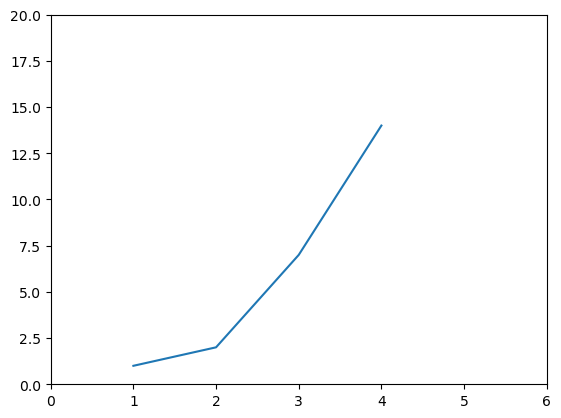

In [23]:
import matplotlib.pyplot as plt

plt.plot([1, 2, 3, 4], [1, 2, 7, 14])
plt.axis([0, 6, 0, 20])
plt.savefig("task3_plot.png", dpi=150)
plt.show()

## Task 4 — My own Matplotlib figure
Gradient descent on a least-squares linear-regression problem. The plot shows the
*excess* training loss L(w_t) − L(w*) per iteration for three learning rates (log scale),
where w* is the exact least-squares solution.

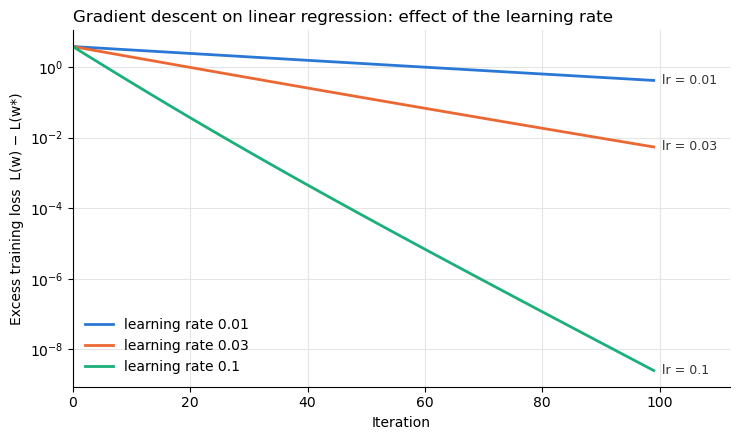

In [24]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(576)
X = np.column_stack([np.ones(200), rng.normal(size=(200, 2))])
w_true = np.array([1.5, -2.0, 0.7])
y = X @ w_true + 0.3 * rng.normal(size=200)

def loss(w):
    return 0.5 * np.mean((X @ w - y) ** 2)

w_star = np.linalg.lstsq(X, y, rcond=None)[0]     # exact optimum
L_star = loss(w_star)

def gd_excess_loss(lr, iters=100):
    w = np.zeros(3)
    out = []
    for _ in range(iters):
        out.append(loss(w) - L_star)
        w -= lr * X.T @ (X @ w - y) / len(y)      # gradient step
    return np.array(out)

rates = [0.01, 0.03, 0.1]
colors = ["#2a78d6", "#eb6834", "#1baf7a"]

fig, ax = plt.subplots(figsize=(7.5, 4.5))
for lr, c in zip(rates, colors):
    E = gd_excess_loss(lr)
    ax.plot(E, color=c, linewidth=2, label=f"learning rate {lr}")
    ax.annotate(f"lr = {lr}", xy=(len(E) - 1, E[-1]), xytext=(6, 0),
                textcoords="offset points", va="center", fontsize=9, color="#333333")

ax.set_yscale("log")
ax.set_xlabel("Iteration")
ax.set_ylabel("Excess training loss  L(w) − L(w*)")
ax.set_title("Gradient descent on linear regression: effect of the learning rate", loc="left")
ax.grid(True, which="major", color="#e5e5e5", linewidth=0.8)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.legend(frameon=False, loc="lower left")
ax.set_xlim(0, 112)
fig.tight_layout()
fig.savefig("task4_plot.png", dpi=150)
plt.show()